# Importation des libraries

In [1]:
import rds2py
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pds
#import libraries
import scanpy as sc
import cell2location as c2l
import squidpy as sq
import commot as ct
import seaborn as sns


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


# Pancreas :  HT224P1

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

#lire les données 
pan224_sc = sc.read("data/data_h5ad/HT224P1-S1.h5ad") # mettre le nom du fichier scRNAseq



pan224_st = sc.read("data/data_h5ad/HT224P1-S1Fc2U1Z1Bs1-SeuratObj.h5ad") # mettre le nom du fichier spatial
pan224_st.obsm['spatial'] = pan224_st.obsm["X_spatial"]
pan224_st.layers["counts"] = pan224_st.X.copy()

print(pan224_sc)
print(pan224_st)

AnnData object with n_obs × n_vars = 2798 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Piece_ID', 'cell_type', 'Original_barcode'
    var: 'features'
AnnData object with n_obs × n_vars = 2295 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'percent_mt', 'percent_rb', 'percent_hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'Tumor_purity_estimate'
    var: 'features'
    obsm: 'X_spatial', 'spatial'
    layers: 'counts'


In [3]:
print("before HVG : ", pan224_sc.shape)
sc.pp.highly_variable_genes(
    pan224_sc,
    n_top_genes=2000,
    subset=False,
    flavor='seurat_v3'
)
print("after HVG : ", pan224_sc.shape)

before HVG :  (2798, 36601)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
after HVG :  (2798, 36601)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Mitochondia-encoded genes (gene names start with prefix mt- or MT-) are irrelevant for spatial mapping because their expression represents technical artifacts in the single cell and nucleus data rather than biological abundance of mitochondria. Yet these genes compose 15-40% of mRNA in each location. Hence, to avoid mapping artifacts we strongly recommend removing mitochondrial genes.

In [4]:
#gènes mitochondriaux
# find mitochondrial (MT) genes
pan224_st.var["MT_gene"] = [
    gene.startswith("MT-") for gene in pan224_st.var["features"]
]

# remove MT genes for spatial mapping (keeping their counts in the object)
pan224_st.obsm["MT"] = pan224_st[:, pan224_st.var["MT_gene"].values].X.toarray()
pan224_st = pan224_st[:, ~pan224_st.var["MT_gene"].values]

In [5]:
shared_features = [
    feature for feature in pan224_st.var_names if feature in pan224_sc.var_names
]
adata_sc = pan224_sc[:, shared_features].copy()
adata_st = pan224_st[:, shared_features].copy()

In [6]:
#configurer et entrainer sur scRNAseq
c2l.models.RegressionModel.setup_anndata(
    adata=adata_sc,
    batch_key="Piece_ID",
    labels_key="cell_type",
)

model = c2l.models.RegressionModel(adata_sc)

model.view_anndata_setup()




Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Piece_ID',
│   'labels_key': 'cell_type',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 2798  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  14   │
│          n_vars          │ 36588 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                    batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Piece_ID'] │ HT224P1-S1 │          0          │
└───────────────────────┴────────────┴─────────────────────┘

                      labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃   Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type'] │      ADM       │          0          │
│                        │    B-cells     │          1          │
│                        │  Ductal-like1  │          2          │
│                        │  Ductal-like2  │          3          │
│                        │  Endothelial   │          4          │
│                        │  Fibroblasts   │          5          │
│                        │     Islets     │          6          │
│                        │  Low quality   │          7          │
│                        │  Macrophages   │          8          │
│                        │      Mast      │          9          │
│                        │ Other_doublets │         10          │
│                        │     Plasma     │         11          │
│                        │    T-cells     │         12          │
│                        │     Tumor      │         13          │
└────────────────────────┴────────────────┴─────────────────────┘

In [12]:
model.train(max_epochs=1000, batch_size=2500, train_size=1, 
            lr=0.01)

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers w

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


In [7]:
model.save("models/ht224p1_sc_regression", overwrite=True)

In [8]:
#Pour charger model
model = c2l.models.RegressionModel.load(
    "models/ht224p1_sc_regression",
    adata=adata_sc
)

INFO     File models/ht224p1_sc_regression/model.pt already downloaded                                             


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1` reached.


RuntimeError: Error(s) in loading state_dict for RegressionBaseModule:
	Missing key(s) in state_dict: "_guide.locs.per_cluster_mu_fg_unconstrained", "_guide.locs.detection_mean_y_e_unconstrained", "_guide.locs.s_g_gene_add_alpha_hyp_unconstrained", "_guide.locs.s_g_gene_add_mean_unconstrained", "_guide.locs.s_g_gene_add_alpha_e_inv_unconstrained", "_guide.locs.s_g_gene_add_unconstrained", "_guide.locs.alpha_g_phi_hyp_unconstrained", "_guide.locs.alpha_g_inverse_unconstrained", "_guide.scales.per_cluster_mu_fg_unconstrained", "_guide.scales.detection_mean_y_e_unconstrained", "_guide.scales.s_g_gene_add_alpha_hyp_unconstrained", "_guide.scales.s_g_gene_add_mean_unconstrained", "_guide.scales.s_g_gene_add_alpha_e_inv_unconstrained", "_guide.scales.s_g_gene_add_unconstrained", "_guide.scales.alpha_g_phi_hyp_unconstrained", "_guide.scales.alpha_g_inverse_unconstrained". 

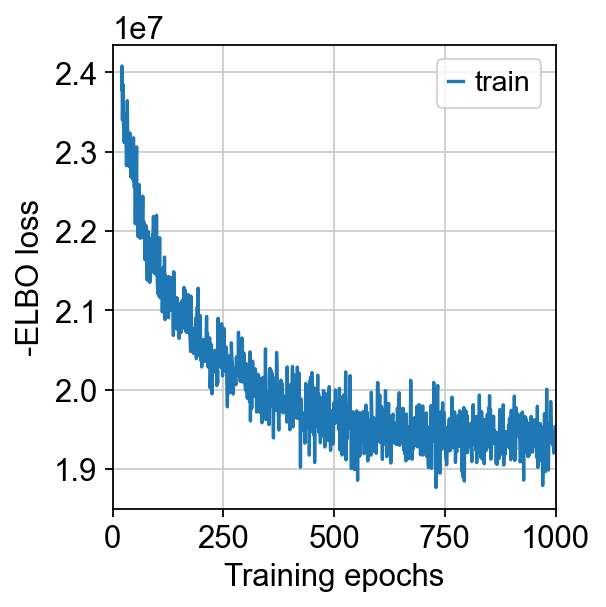

In [59]:
model.plot_history(20)

In [20]:
# Exporter signatures
model.export_posterior(
    adata_sc,
    sample_kwargs={"num_samples": 1000, "batch_size": 2500,},
)

inf_aver = adata_sc.varm['means_per_cluster_mu_fg']  # genes x cell_types
inf_aver.to_csv('signatures_HT224.csv')  # réutilisable

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/model/base/_pyromixin.py:499: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


Sampling local variables, batch:   0%|          | 0/2 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

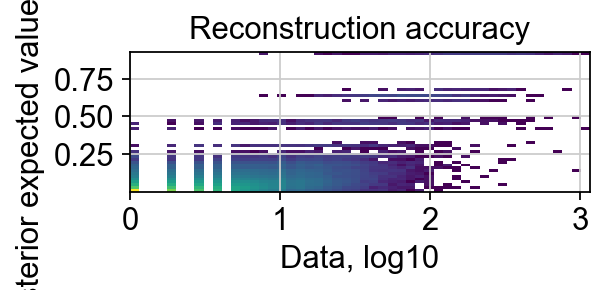

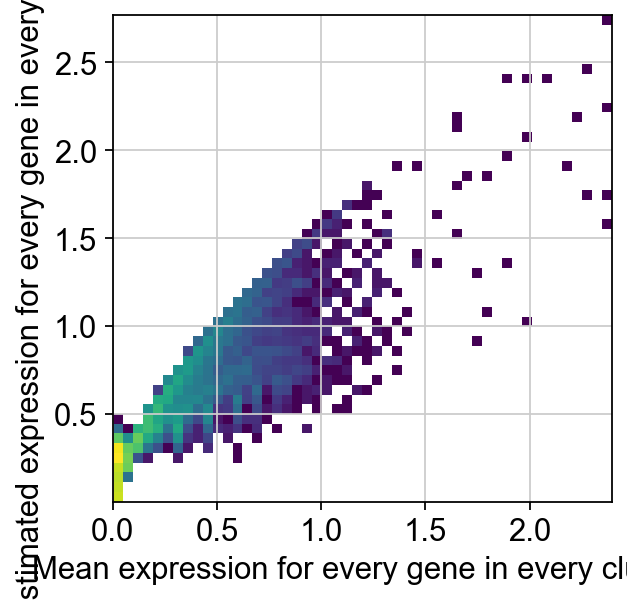

In [22]:
model.plot_QC()  # diagonal reconstruction

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:631: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, self.device = parse_device_args(
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(a

Training:   0%|          | 0/800 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=800` reached.


RuntimeError: self.samples is missing, please run self.export_posterior() first

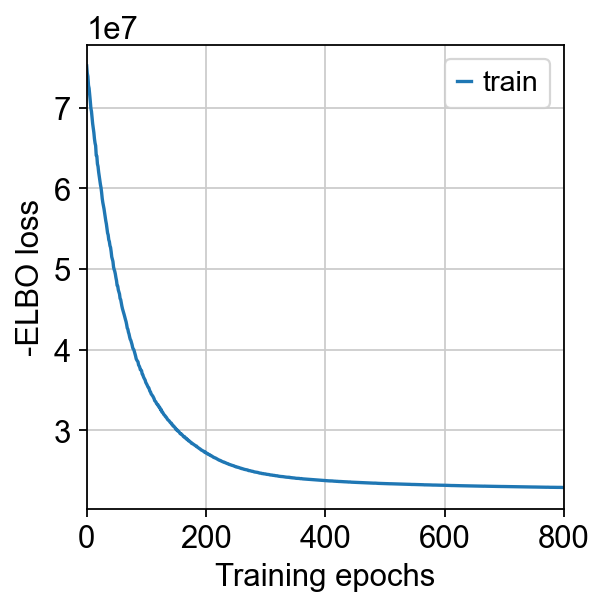

In [63]:
#modele spatial (deconvolution)
c2l.models.Cell2location.setup_anndata(adata_st,layer="counts")
mod_sp = c2l.models.Cell2location(adata_st, cell_state_df=inf_aver,
                                  N_cells_per_location=8)  # ~8 cellules/spot

mod_sp.train(max_epochs=800,lr = 0.01)  # plus long, GPU recommandé
mod_sp.plot_history()  # convergence
mod_sp.plot_QC()  # diagonal




In [65]:
# Exporter abondances (q05 = confiance haute)
adata_st = mod_sp.export_posterior(adata_st, 
                                   sample_kwargs={'num_samples':1000})
adata_st.obs[mod_sp.factor_names_] = adata_st.obsm['q05_cell_abundance_w_sf']

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/model/base/_pyromixin.py:499: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


Sampling local variables, batch:   0%|          | 0/18 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

In [64]:
mod_sp.save("models/ht224p1_spatial", overwrite=True)

In [97]:
# 1. Extraire counts bruts
raw_counts = adata_st.layers["counts"].copy()

# 2. Nettoyer var : retirer `_index` si présent
var = adata_st.var.copy()
if "_index" in var.columns:
    var = var.drop(columns=["_index"])

# 3. Créer un nouvel AnnData pour raw
adata_st.raw = sc.AnnData(
    X=raw_counts,
    obs=adata_st.obs.copy(),
    var=var
)


In [102]:
# 1. Extraire counts bruts
raw_counts = adata_sc.layers["counts"].copy() if "counts" in adata_sc.layers else adata_sc.X.copy()

# 2. Nettoyer var : retirer `_index` si présent
var = adata_sc.var.copy()
if "_index" in var.columns:
    var = var.drop(columns=["_index"])

# 3. Recréer un raw propre
adata_sc.raw = sc.AnnData(
    X=raw_counts,
    obs=adata_sc.obs.copy(),
    var=var
)


In [149]:
adata_st.obs["cell_type"] = adata_st.obs["cell_type"].apply(lambda x: ", ".join(x) if isinstance(x, list) else str(x))


In [150]:
#adata_st.write("data/data_processed/HT224P1_spatial.h5ad")
#adata_sc.write("data/data_processed/HT224P1_sc.h5ad")


### Visualisation de déconvolution

In [2]:
adata_st = sc.read("data/data_processed/HT224P1_spatial.h5ad")
adata_sc = sc.read("data/data_processed/HT224P1_sc.h5ad")

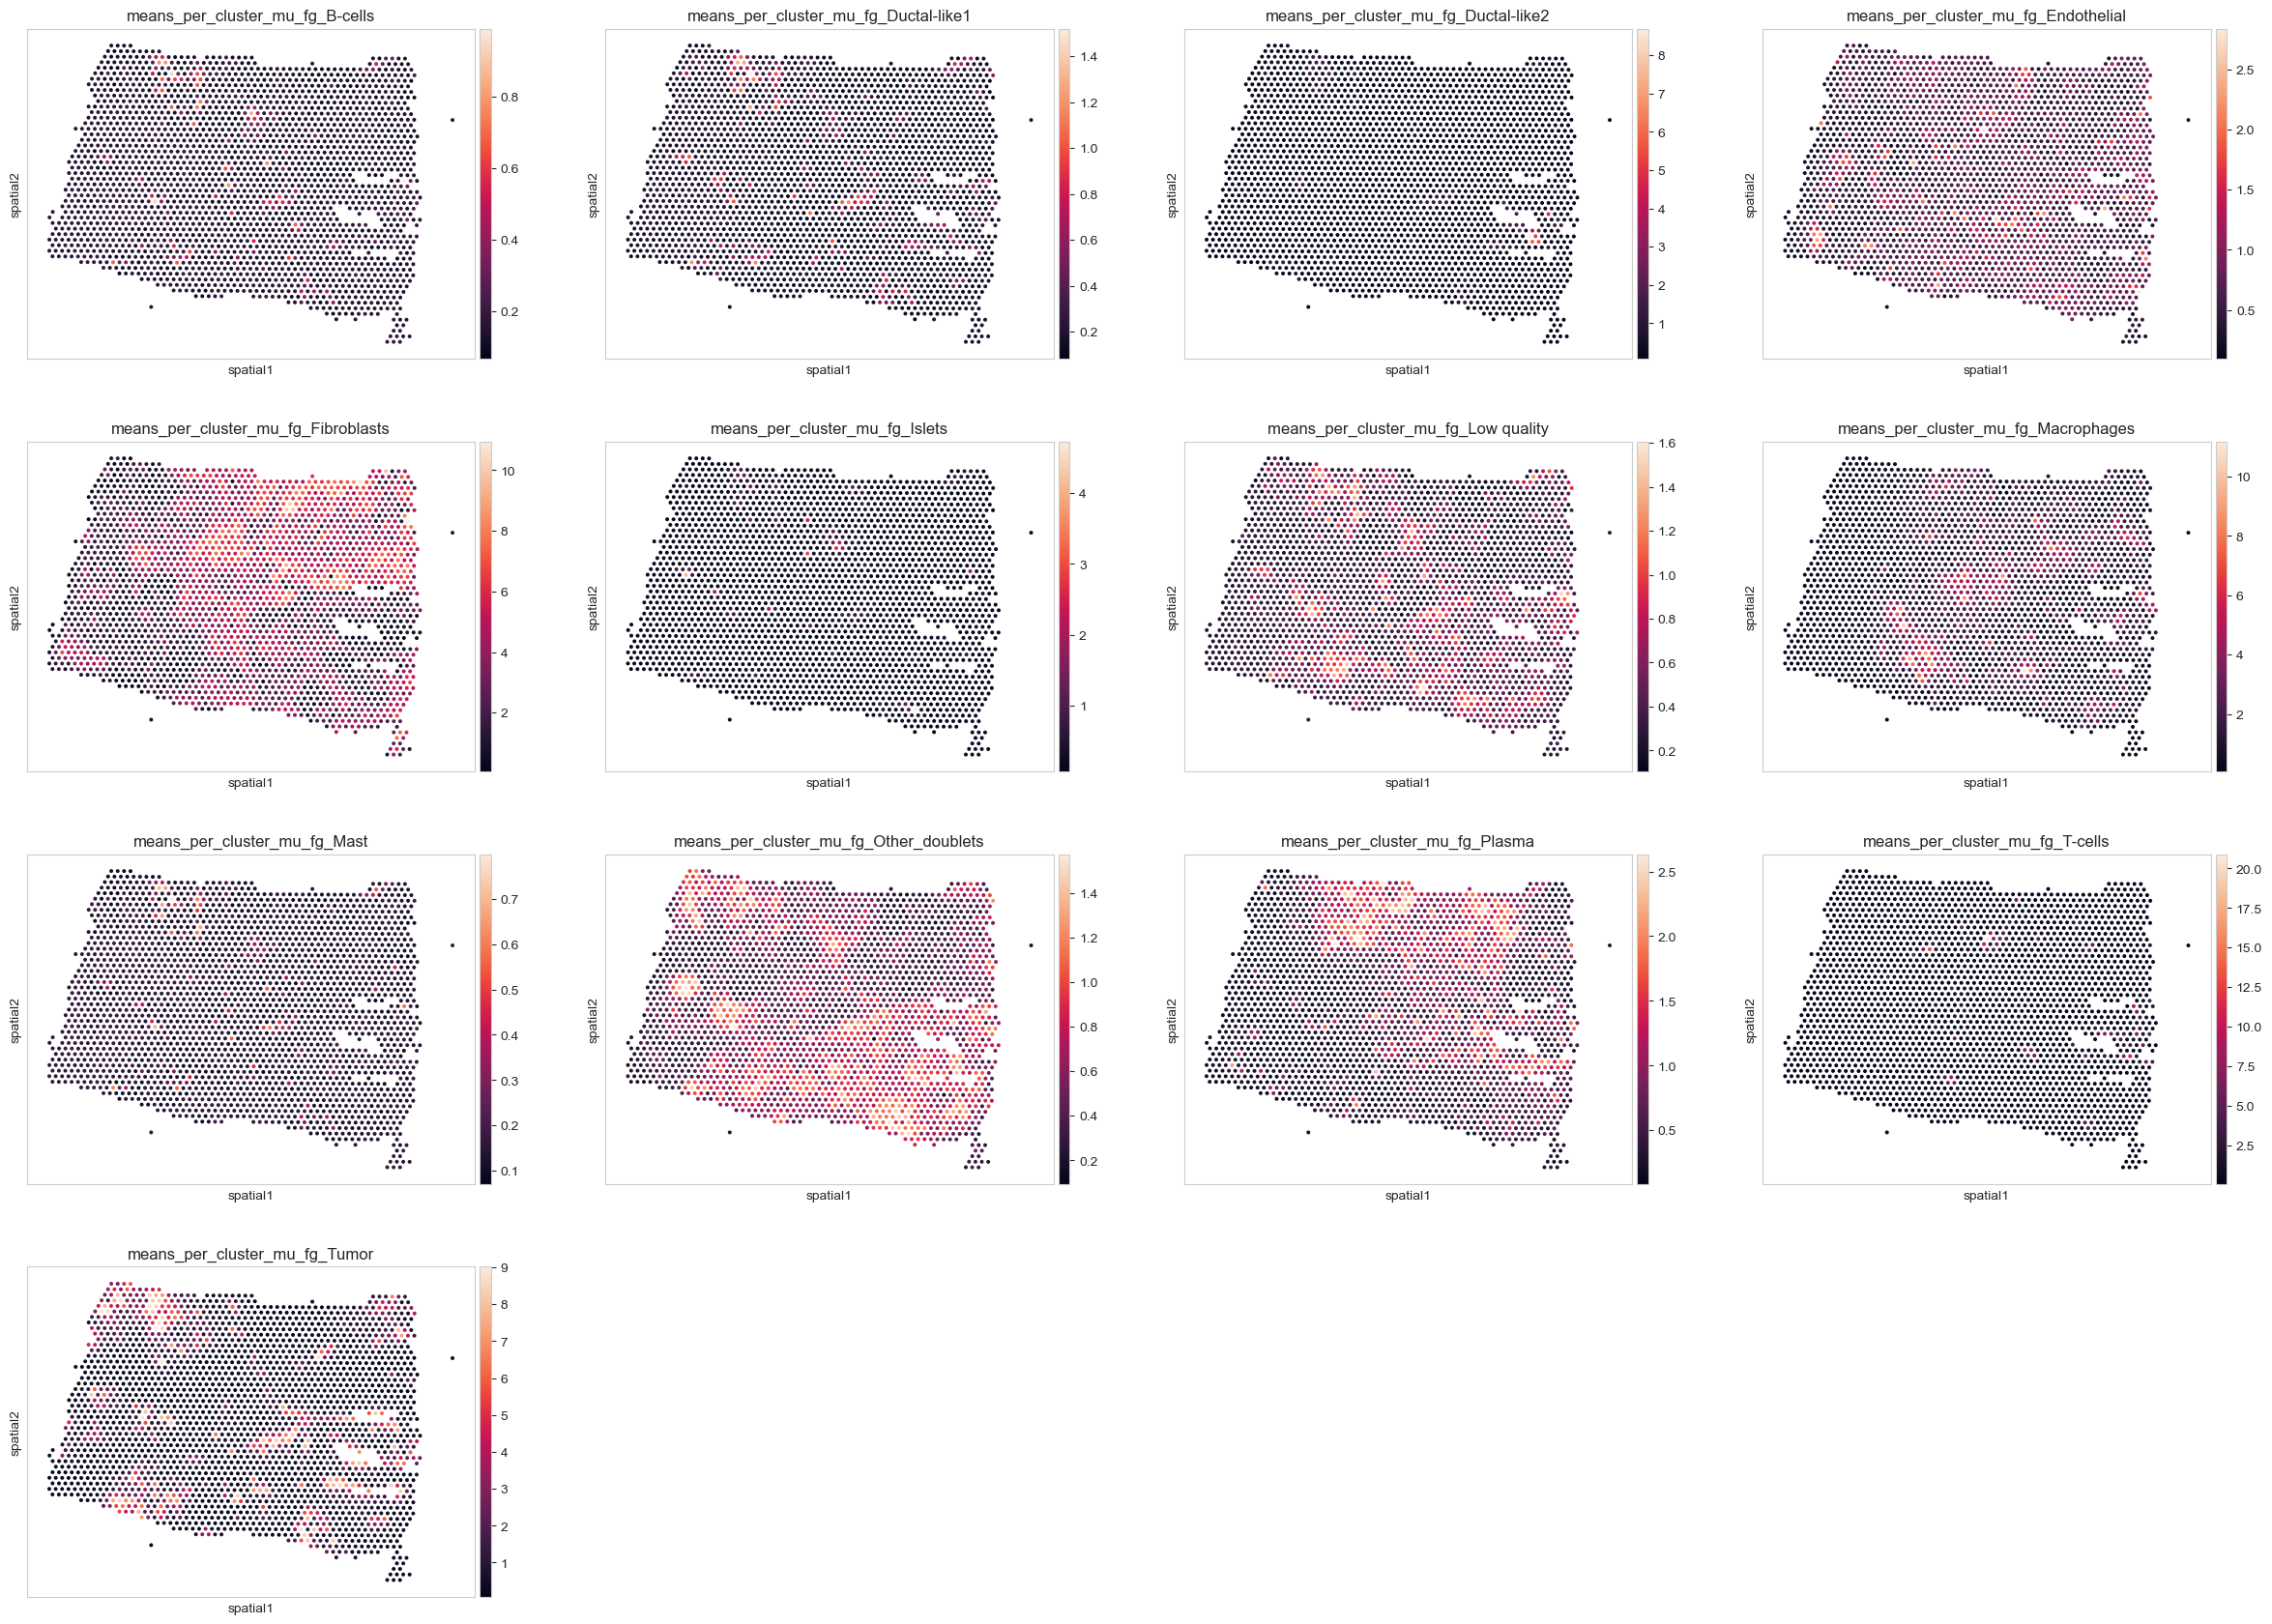

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


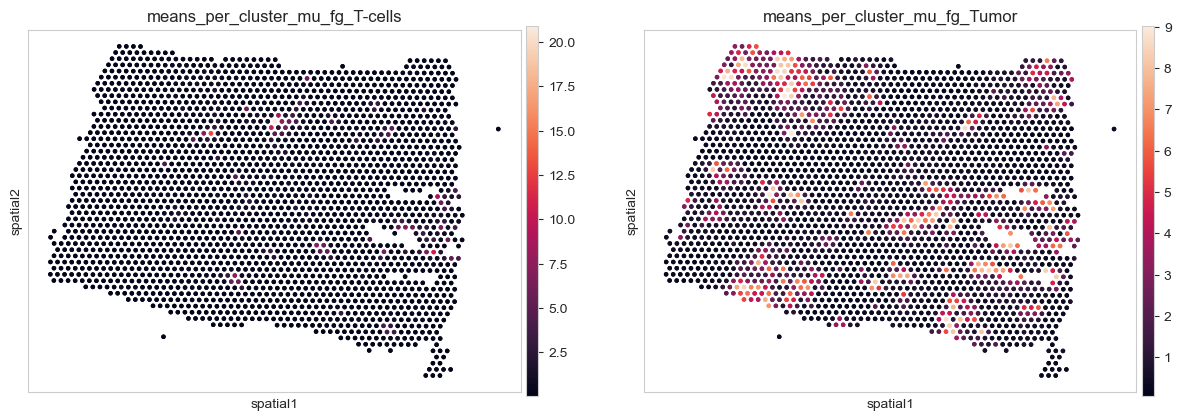

In [4]:
#visualization et validation

sc.pl.spatial(
    adata_st,
    color=[
        'means_per_cluster_mu_fg_B-cells',
       'means_per_cluster_mu_fg_Ductal-like1',
       'means_per_cluster_mu_fg_Ductal-like2',
       'means_per_cluster_mu_fg_Endothelial',
       'means_per_cluster_mu_fg_Fibroblasts', 'means_per_cluster_mu_fg_Islets',
       'means_per_cluster_mu_fg_Low quality',
       'means_per_cluster_mu_fg_Macrophages', 'means_per_cluster_mu_fg_Mast',
       'means_per_cluster_mu_fg_Other_doublets',
       'means_per_cluster_mu_fg_Plasma', 'means_per_cluster_mu_fg_T-cells',
       'means_per_cluster_mu_fg_Tumor'
    ],
    spot_size=150
)

sq.pl.spatial_scatter(adata_st, shape = None, 
                      color=['means_per_cluster_mu_fg_T-cells',
                             'means_per_cluster_mu_fg_Tumor'],
                      size = 20)  # après clustering


# Clustering régions tissulaires
sc.pp.neighbors(adata_st, use_rep='q05_cell_abundance_w_sf')
sc.tl.leiden(adata_st)
sc.tl.umap(adata_st)



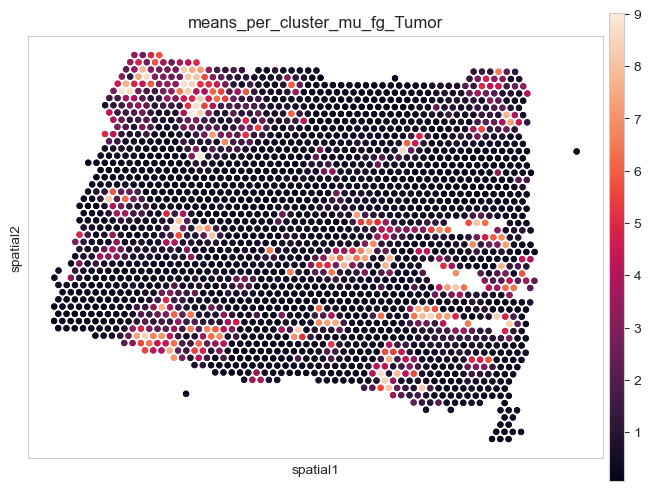

In [32]:

sq.pl.spatial_scatter(adata_st, shape = None, 
                      color=[
                             'means_per_cluster_mu_fg_Tumor'],
                      size = 50)  # après clustering

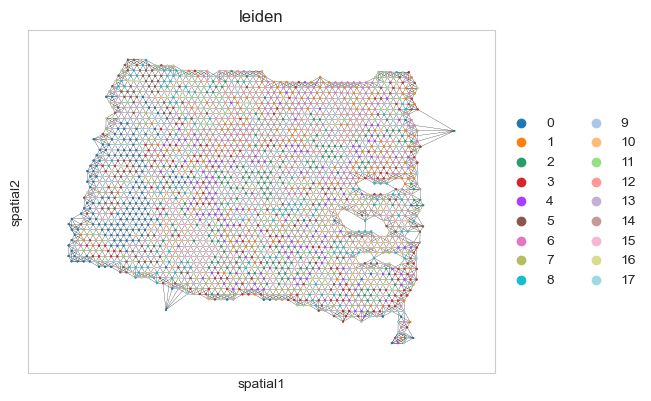

In [5]:

sq.pl.spatial_scatter(
    adata_st,
    color="leiden",
    connectivity_key="spatial_connectivities",
    edges_color="black",
    shape=None,
    edges_width=0.1,
    size=1,
)

In [104]:
adata_sc

AnnData object with n_obs × n_vars = 2798 × 36588
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Piece_ID', 'cell_type', 'Original_barcode'
    var: 'features'

In [4]:
def mean_par_typecell(adata, basename = "sein_ht224p1",threshold_ratio= 0.8):
    def assign_celltypes(row):
        m = row.max()
        return row[row >= threshold_ratio * m].index.tolist()
    
    def mean_celltypes(df):
        df =df.explode("cell_type")
        df["cell_type"] = df["cell_type"].astype(str)
        lr_cols = [c for c in df.columns if c != "cell_type"]
        return df,df.groupby("cell_type")[lr_cols].mean()
    #Récupérer les means d'abondance de cellule
    mat = pds.DataFrame(
        adata_st.obsm['means_cell_abundance_w_sf'],
        index=adata_st.obs_names,
    )
    mat.columns = extract_celltype_names(adata.obsm['means_cell_abundance_w_sf'].columns)
    
    #attribution de type de cellule pour chaque spot
    adata_st.obs["cell_type"]=mat.apply(assign_celltypes, axis=1)
    
    sender = pds.DataFrame(adata.obsm[f"commot-{basename}-sum-sender"].copy())
    receiver = pds.DataFrame(adata.obsm[f"commot-{basename}-sum-receiver"].copy())
    
    sender["cell_type"] =adata.obs["cell_type"].copy()
    receiver["cell_type"] = adata.obs["cell_type"].copy()


    sender,sender_mean = mean_celltypes(sender)
    receiver,receiver_mean = mean_celltypes(receiver)
    return sender, receiver, sender_mean, receiver_mean

In [5]:
import re

def extract_celltype_names(means_col):
    
    # On retire le préfixe
    prefix = "meanscell_abundance_w_sf_means_per_cluster_mu_fg_"
    celltypes = [col.replace(prefix, "") for col in means_col]
    
    return celltypes

In [13]:
sender, receiver, sender_mean, receiver_mean = mean_par_typecell(adata_st)

In [146]:
import os 
def save_mean(sender, receiver, sender_mean, receiver_mean, folder_name, base_dir="ligands_receptors"):

    output_dir = os.path.join(base_dir, folder_name)

    # Vérification + création si nécessaire
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Dossier créé : {output_dir}")
    else:
        print(f"Le dossier existe déjà : {output_dir}")

    #chemins des fichiers
    sender_path = os.path.join(output_dir, "sender.csv")
    sender_mean_path = os.path.join(output_dir, "sender_mean.csv")
    receiver_path = os.path.join(output_dir, "receiver.csv")
    receiver_mean_path = os.path.join(output_dir, "receiver_mean.csv")

    # 3. sauvegarde en CSV
    sender.to_csv(sender_path)
    sender_mean.to_csv(sender_mean_path)
    receiver.to_csv(receiver_path)
    receiver_mean.to_csv(receiver_mean_path)

    print(f"Fichiers sauvegardés dans : {output_dir}")


In [6]:
celltypes = extract_celltype_names(adata_st.obsm['means_cell_abundance_w_sf'].columns)

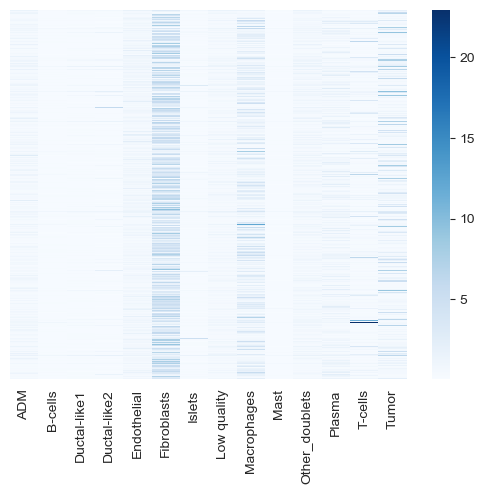

In [11]:
sns.heatmap(adata_st.obsm['means_cell_abundance_w_sf'],
            xticklabels=celltypes, 
            yticklabels=False,
            cmap = "Blues")
plt.show()

In [147]:
save_mean(sender, receiver, sender_mean, receiver_mean,folder_name = "pancreas_ht224p1")

Le dossier existe déjà : ligands_receptors/pancreas_ht224p1
Fichiers sauvegardés dans : ligands_receptors/pancreas_ht224p1


## Cell-Cell Communication

In [6]:
df_cellchat = ct.pp.ligand_receptor_database(species='human',database='CellChat')
print(df_cellchat.shape)

(1199, 4)


In [7]:
df_comm = ct.tl.spatial_communication(adata_st,
    database_name='sein_ht224p1',
    df_ligrec=df_cellchat, dis_thr=500 , heteromeric=True)

<Axes: ylabel='cell_type'>

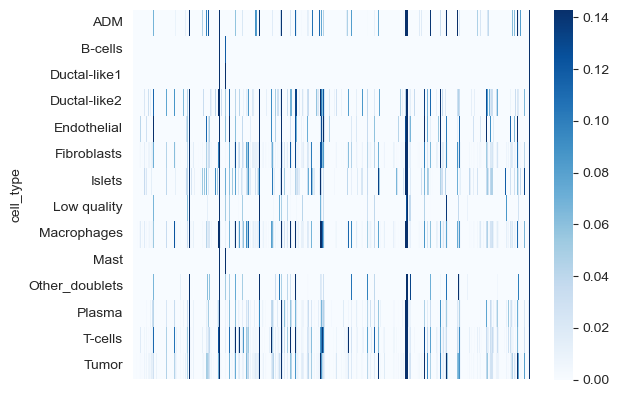

In [33]:
sns.heatmap(receiver_mean,cmap="Blues",
            xticklabels=False, robust=True
            )

<Axes: >

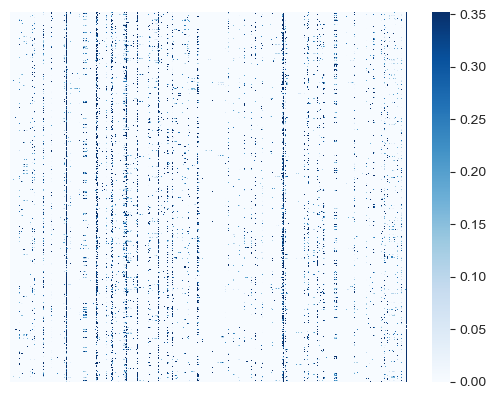

In [25]:
sns.heatmap(adata_st.obsm['commot-sein_ht224p1-sum-sender'],
            xticklabels=False, yticklabels=False,cmap ="Blues",
            robust = True)

<Axes: >

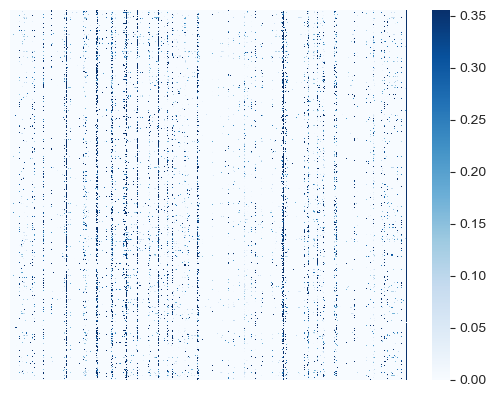

In [26]:
sns.heatmap(adata_st.obsm['commot-sein_ht224p1-sum-receiver'],
            xticklabels=False, yticklabels=False,cmap ="Blues",
            robust = True)

Text(0.5, 1.0, 'Receiver')

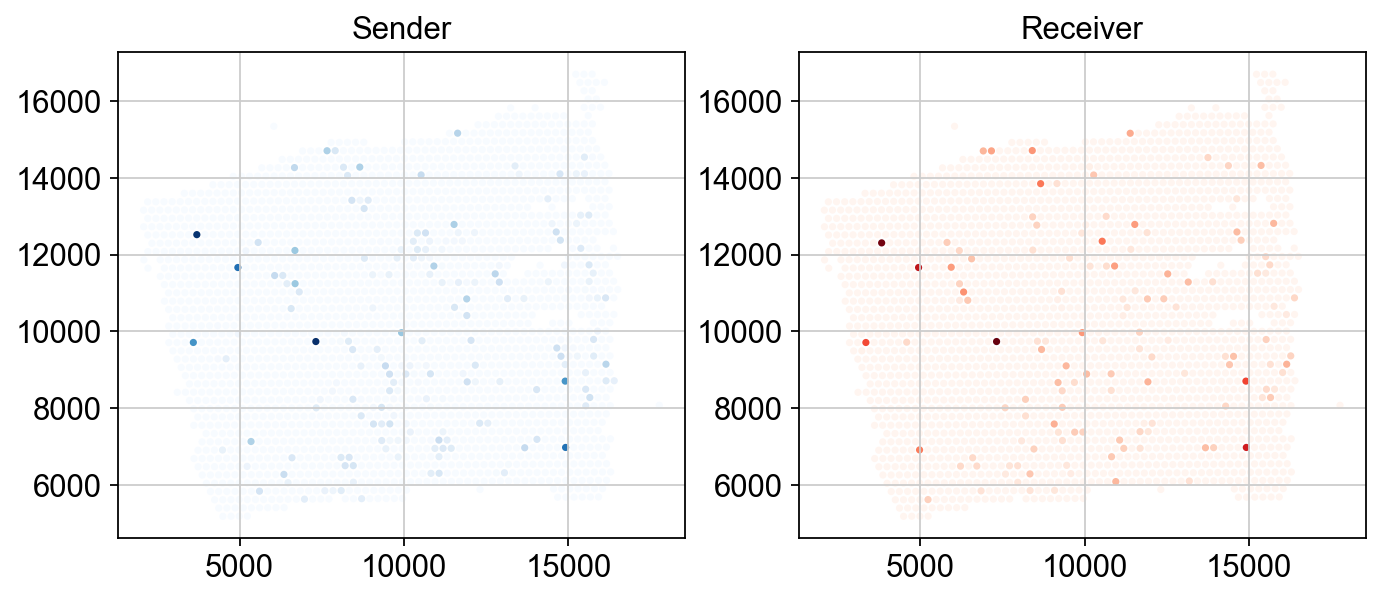

In [25]:
#Visualize signaling level 
pts = adata_st.obsm['spatial']
s = adata_st.obsm['commot-sein_ht224p1-sum-sender']['s-CCL14-CCR1']
r = adata_st.obsm['commot-sein_ht224p1-sum-receiver']['r-CCL14-CCR1']
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(pts[:,0], pts[:,1], c=s, s=5, cmap='Blues')
ax[0].set_title('Sender')
ax[1].scatter(pts[:,0], pts[:,1], c=r, s=5, cmap='Reds')
ax[1].set_title('Receiver')

IndexError: list index out of range

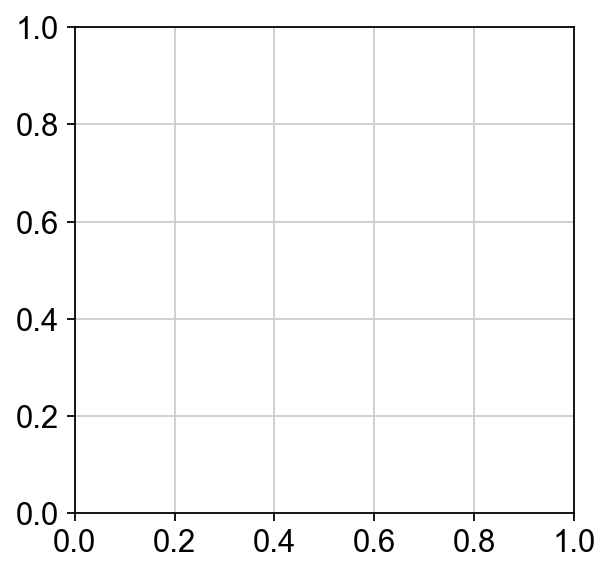

In [26]:
# spatial direction of a signalling pathway: ex PSAP (à modifier)
ct.tl.communication_direction(adata_st, database_name='sein_ht224p1', pathway_name='CCL14-CCR1', k=5)
ct.pl.plot_cell_communication(adata_st, database_name='sein_ht224p1', pathway_name='CCL14-CCR1', plot_method='grid', background_legend=True,
    scale=0.00003, ndsize=8, grid_density=0.4, summary='sender', background='image', clustering='leiden', cmap='Alphabet',
    normalize_v = True, normalize_v_quantile=0.995)

In [13]:
adata_st.obsm

AxisArrays with keys: MT, X_pca, X_spatial, X_umap, means_cell_abundance_w_sf, q05_cell_abundance_w_sf, q95_cell_abundance_w_sf, spatial, stds_cell_abundance_w_sf, commot-sein_ht224p1-sum-sender, commot-sein_ht224p1-sum-receiver

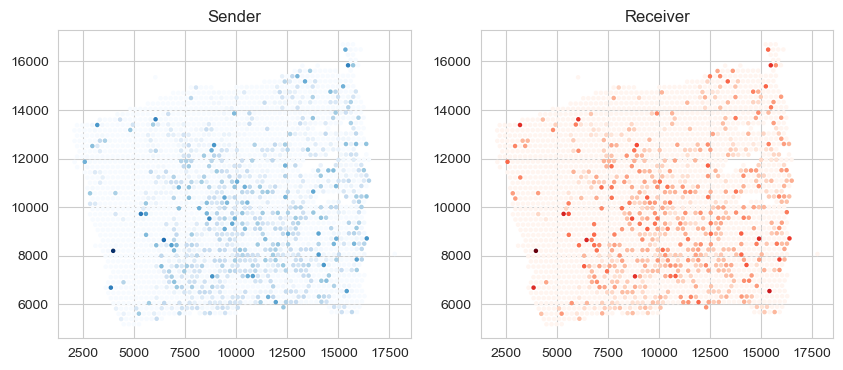

In [15]:
# visualiser le niveau de signal envoyé et reçu d'une paire ligand-recepteur (ex: Fgf1-Fgfr1)

pts = adata_st.obsm['spatial']
s = adata_st.obsm['commot-sein_ht224p1-sum-sender']['s-MDK-ITGA4_ITGB1']
r = adata_st.obsm['commot-sein_ht224p1-sum-receiver']['r-MDK-ITGA4_ITGB1']

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(pts[:,0], pts[:,1], c=s, s=5, cmap='Blues')
ax[0].set_title('Sender')
ax[1].scatter(pts[:,0], pts[:,1], c=r, s=5, cmap='Reds')
ax[1].set_title('Receiver')
plt.show()

In [ ]:
#visualiser les directions du signal comme un champ vectoriel

ct.tl.communication_direction(adata_st, database_name='cellchat', lr_pair=('Fgf1','Fgfr1'), k=5)

ct.pl.plot_cell_communication(adata_st, database_name='cellchat', lr_pair=('Fgf1','Fgfr1'),
                             plot_method='grid', background_legend=True,
                             scale=0.00003, ndsize=8, grid_density=0.4,
                             summary='sender', background='image', cmap='Alphabet',
                             normalize_v=True, normalize_v_quantile=0.995)


In [16]:
# visualiser signaux reçus 

ct.pl.plot_cell_communication(adata_st, database_name='sein_ht224p1',
                             plot_method='grid', background_legend=True,
                             scale=0.00003, ndsize=8, grid_density=0.4,
                             summary='receiver', background='summary', cmap='Reds',
                             normalize_v=True, normalize_v_quantile=0.995)


KeyError: 'commot_receiver_vf-sein_ht224p1-total-total'

In [87]:
adata_st.uns['commot-sein_ht224p1-info']

{'df_ligrec':       ligand       receptor    pathway
 0      TGFB1  TGFBR1_TGFBR2       TGFb
 1      TGFB2  TGFBR1_TGFBR2       TGFb
 2      TGFB3  TGFBR1_TGFBR2       TGFb
 3      TGFB1  ACVR1B_TGFBR2       TGFb
 4      TGFB1  ACVR1C_TGFBR2       TGFb
 ...      ...            ...        ...
 1189   UTS2B          UTS2R  UROTENSIN
 1190   UTS2B          SSTR5  UROTENSIN
 1191    BAG6           NCR3        BAG
 1192  LGALS9         HAVCR2   GALECTIN
 1193  LGALS9           CD44   GALECTIN
 
 [1194 rows x 3 columns],
 'distance_threshold': 500}

In [88]:
lr_table = pds.DataFrame(adata_st.uns['commot-sein_ht224p1-info']['df_ligrec']) # colonnes: 'ligand','receptor'
n_pairs = lr_table.shape[0]
cell_ids = adata_st.obs_names

In [90]:
sender = pds.DataFrame(adata_st.obsm["commot-sein_ht224p1-sum-sender"].copy())  # shape: (n_cells, n_pairs)
receiver = pds.DataFrame(adata_st.obsm["commot-sein_ht224p1-sum-receiver"].copy())  # shape: (n_cells, n_pairs)

rows = []

for k in range(n_pairs):
    ligand = lr_table.iloc[k]["ligand"]
    receptor = lr_table.iloc[k]["receptor"]

    # produit extérieur source × cible
    mat = np.outer(sender[:, k], receiver[:, k])

    # récupérer uniquement les interactions > 0
    source_idx, target_idx = np.nonzero(mat)

    scores = mat[source_idx, target_idx]

    for s, t, sc in zip(source_idx, target_idx, scores):
        rows.append({
            "source": cell_ids[s],
            "target": cell_ids[t],
            "ligand": ligand,
            "receptor": receptor,
            "score": sc
        })

df_lr = pds.DataFrame(rows)

InvalidIndexError: (slice(None, None, None), 0)